# Spindown Analysis
Extracts the spin decay time τ from LES YAW monitor data using the Hilbert transform.

**Method:** bandpass filter → Hilbert transform → instantaneous frequency → exponential fit  
**Model:** f(t) = A · exp(−t/τ)  (free spindown, no steady-state offset)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import h5py
from datetime import datetime, timezone
from scipy.signal import decimate, butter, sosfiltfilt, hilbert
from scipy.optimize import curve_fit
from scipy.ndimage import uniform_filter1d

In [2]:
FILENAME_PIT = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/LES_pit/Y1_RDS-LES_PIT_OUT_DQ_1464540775_1464545815.0.h5'
FILENAME_YAW = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/LES_yaw/Y1_RDS-LES_YAW_IN1_DQ_1464540775_1464545815.0.h5'
FILENAME_V1  = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/Electrodes/Y1_RDS-OUTS_V1_OUT_DQ_1464540775_1464545815.0.h5'

# GPS → UTC: GPS epoch is Jan 6 1980; 18 leap seconds as of 2025
# NOTE: cymac1 GPS clock is +5836 s fast vs true GPS (measured 2026-06-03)
# True GPS = cymac GPS - 5836. Timestamps in HDF5 files use cymac GPS.
GPS_UNIX_OFFSET = 315964800 - 18

def gps_to_dt(gps):
    return datetime.fromtimestamp(gps + GPS_UNIX_OFFSET, tz=timezone.utc)

def dt_to_gps(dt):
    return dt.timestamp() - GPS_UNIX_OFFSET

In [3]:
with h5py.File(FILENAME_PIT, 'r') as f:
    FS        = float(f.attrs['sample_rate'])
    gps_start = float(f.attrs['gps_start'])
    gps_end   = float(f.attrs['gps_end'])
    n_total   = f['data'].shape[0]

print(f"Rate:     {FS} Hz")
print(f"Samples:  {n_total:,}  ({n_total / FS / 3600:.2f} h)")
print(f"Start:    {gps_to_dt(gps_start)}")
print(f"End:      {gps_to_dt(gps_end)}")

Rate:     1024.0 Hz
Samples:  4,915,200  (1.33 h)
Start:    2026-06-03 16:52:37+00:00
End:      2026-06-03 18:16:37+00:00


## 2. Overview: Full Time Series
Strided read (every 256th sample → 4 Hz) for fast visual inspection across the full 24h window.  
Use this to find the spindown region, then set `RING_START` / `RING_END` below.

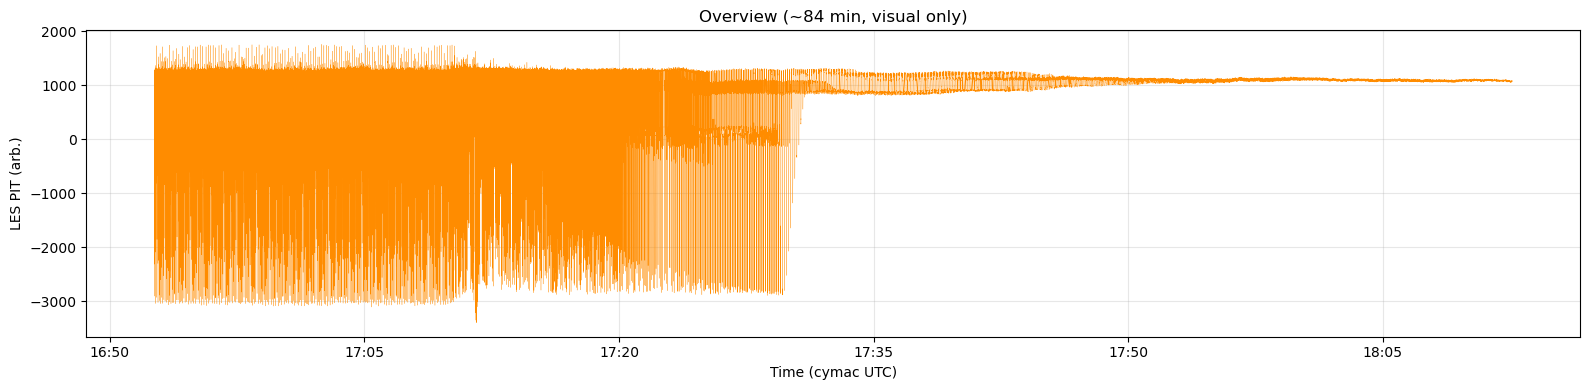

In [6]:
# Strided read — no anti-alias filter, for visual inspection only
STRIDE = 32  # 1024 Hz → 32 Hz effective
t_ov, y_ov = [], []

with h5py.File(FILENAME_PIT, 'r') as f:
    segs = f['segments/gps_start'][:].astype(np.float64)
    idxs = f['segments/index_start'][:].astype(np.int64)
    lens = f['segments/length'][:].astype(np.int64)
    dset = f['data']
    for gps0, ix, n in zip(segs, idxs, lens):
        y_seg = dset[ix : ix + n : STRIDE].astype(np.float32)
        t_seg = gps0 + np.arange(len(y_seg)) * STRIDE / 1024.0
        t_ov.append(t_seg)
        y_ov.append(y_seg)

t_ov = np.concatenate(t_ov)
y_ov = np.concatenate(y_ov)

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot([gps_to_dt(t) for t in t_ov], y_ov, linewidth=0.2, color='darkorange')
ax.set_xlabel('Time (cymac UTC)')
ax.set_ylabel('LES PIT (arb.)')
ax.set_title('Overview (~84 min, visual only)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=15))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
def load_channel(filename, fs_out=64.0, gps_t0=None, gps_t1=None):
    """Load an HDF5 channel, decimate to fs_out Hz. Optionally restrict to [gps_t0, gps_t1]."""
    t_list, y_list = [], []
    with h5py.File(filename, 'r') as f:
        fs   = float(f.attrs['sample_rate'])
        segs = f['segments/gps_start'][:].astype(np.float64)
        idxs = f['segments/index_start'][:].astype(np.int64)
        lens = f['segments/length'][:].astype(np.int64)
        dset = f['data']
        for gps0, ix, n in zip(segs, idxs, lens):
            gps1 = gps0 + n / fs
            if gps_t0 and gps1 < gps_t0: continue
            if gps_t1 and gps0 > gps_t1: continue
            seg = dset[ix : ix + n].astype(np.float64)
            seg = decimate(decimate(seg, 4, zero_phase=True), 4, zero_phase=True)  # ÷16 → 64 Hz
            t_seg = gps0 + np.arange(len(seg)) / fs_out
            t_list.append(t_seg)
            y_list.append(seg)
    t = np.concatenate(t_list)
    y = np.concatenate(y_list)
    if gps_t0: mask = t >= gps_t0; t, y = t[mask], y[mask]
    if gps_t1: mask = t <= gps_t1; t, y = t[mask], y[mask]
    return t, y

# ── Full 84-min window (cymac GPS 1464540775→1464545815) ─────────────────────
# Electrode turn-off at cymac GPS ~1464541833 → ~18 min into file
# Times below are in "cymac UTC" (cymac GPS + GPS_UNIX_OFFSET) — not true UTC
RING_START = datetime(2026, 6, 3, 16, 39, 0, tzinfo=timezone.utc)
RING_END   = datetime(2026, 6, 3, 18,  3, 0, tzinfo=timezone.utc)
# ─────────────────────────────────────────────────────────────────────────────

gps_t0 = dt_to_gps(RING_START)
gps_t1 = dt_to_gps(RING_END)

FS_RING = 64.0
t_pit, y_pit = load_channel(FILENAME_PIT, FS_RING, gps_t0, gps_t1)
t_yaw, y_yaw = load_channel(FILENAME_YAW, FS_RING)

print(f"PIT: {len(y_pit):,} samples  {gps_to_dt(t_pit[0])} → {gps_to_dt(t_pit[-1])}")
print(f"YAW: {len(y_yaw):,} samples  {gps_to_dt(t_yaw[0])} → {gps_to_dt(t_yaw[-1])}")

PIT: 270,273 samples  2026-06-03 16:52:37+00:00 → 2026-06-03 18:03:00+00:00
YAW: 307,200 samples  2026-06-03 16:52:37+00:00 → 2026-06-03 18:12:36.984375+00:00


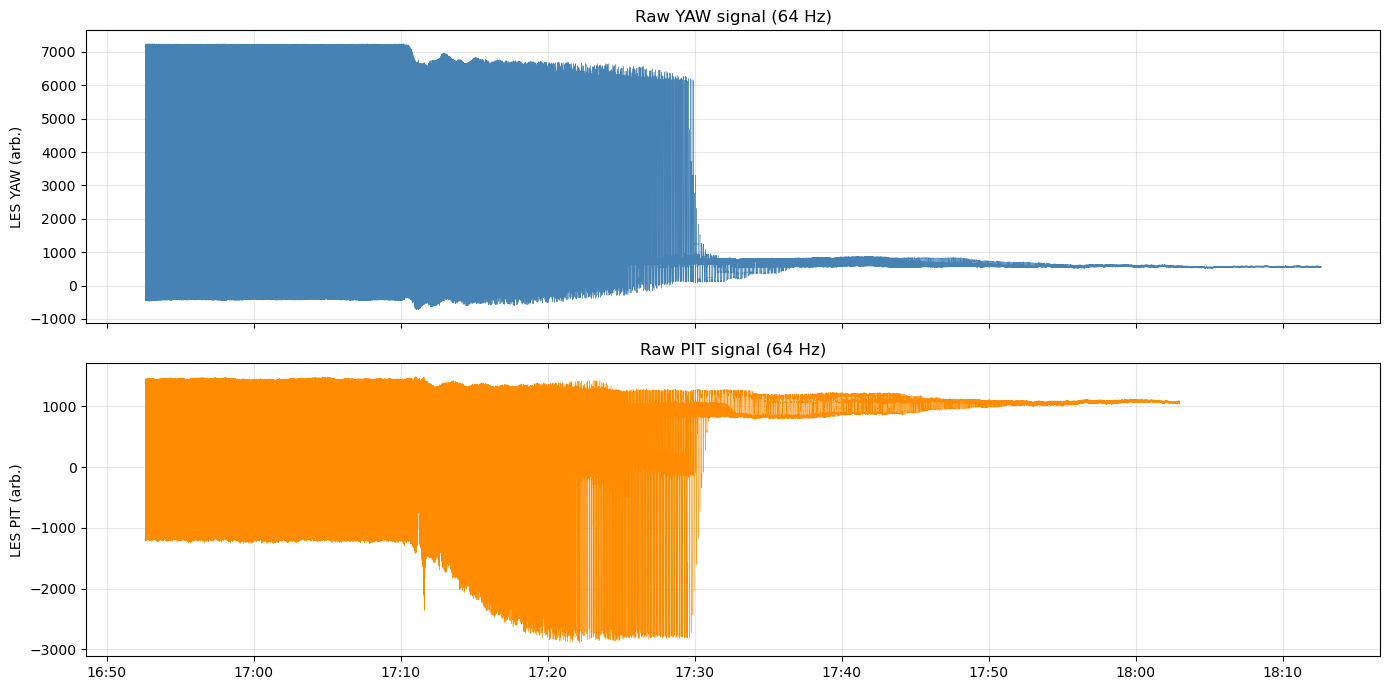

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot([gps_to_dt(t) for t in t_yaw], y_yaw, linewidth=0.3, color='steelblue')
axes[0].set_ylabel('LES YAW (arb.)')
axes[0].set_title('Raw YAW signal (64 Hz)')
axes[0].grid(True, alpha=0.3)

axes[1].plot([gps_to_dt(t) for t in t_pit], y_pit, linewidth=0.3, color='darkorange')
axes[1].set_ylabel('LES PIT (arb.)')
axes[1].set_title('Raw PIT signal (64 Hz)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[1].xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Bandpass Filter
Zero-phase Butterworth bandpass to isolate the spin signal.  
Low cut removes DC drift; high cut removes noise above the spin frequency range.

In [37]:
# ── Adjust if spin frequency range is different ───────────────────────────────
F_LOW  = 0.005  # Hz – removes DC drift; low enough to track spin down to near-zero
F_HIGH = 6.0    # Hz – above the 4 Hz electrode drive frequency
# ─────────────────────────────────────────────────────────────────────────────

sos     = butter(4, [F_LOW, F_HIGH], btype='bandpass', fs=FS_RING, output='sos')
y_yaw_f = sosfiltfilt(sos, y_yaw)
y_pit_f = sosfiltfilt(sos, y_pit)
print(f"Bandpass applied: {F_LOW}–{F_HIGH} Hz")

Bandpass applied: 0.005–6.0 Hz


## 4. Hilbert Transform: Instantaneous Amplitude and Frequency
The analytic signal gives the amplitude envelope and instantaneous phase.  
Instantaneous frequency = dφ/dt / (2π).  
A uniform smoothing filter removes sample-to-sample noise.

In [38]:
def hilbert_freq(y_filt, fs, smooth_sec=30.0):
    """Return (inst_freq, envelope, dt_half) — all arrays length N-1, aligned."""
    analytic  = hilbert(y_filt)
    envelope  = np.abs(analytic)
    phase     = np.unwrap(np.angle(analytic))
    dt        = 1.0 / fs
    inst_freq = np.diff(phase) / (2 * np.pi * dt)
    win       = max(1, int(smooth_sec * fs))
    # trim envelope to N-1 so it aligns with inst_freq
    return (uniform_filter1d(inst_freq,      size=win),
            uniform_filter1d(envelope[:-1],  size=win),
            dt / 2)

# ── Smoothing window ──────────────────────────────────────────────────────────
SMOOTH_SEC = 30.0
# ─────────────────────────────────────────────────────────────────────────────

freq_yaw, env_yaw, dt_half = hilbert_freq(y_yaw_f, FS_RING, SMOOTH_SEC)
freq_pit, env_pit, _       = hilbert_freq(y_pit_f, FS_RING, SMOOTH_SEC)

t_freq_yaw = t_yaw[:-1] + dt_half
t_freq_pit = t_pit[:-1] + dt_half

print(f"Array lengths — freq: {len(freq_pit)}, envelope: {len(env_pit)}  (should match)")
print(f"YAW freq range: {freq_yaw.min():.3f} – {freq_yaw.max():.3f} Hz")
print(f"PIT freq range: {freq_pit.min():.3f} – {freq_pit.max():.3f} Hz")

Array lengths — freq: 270272, envelope: 270272  (should match)
YAW freq range: -0.007 – 6.998 Hz
PIT freq range: -0.013 – 5.325 Hz


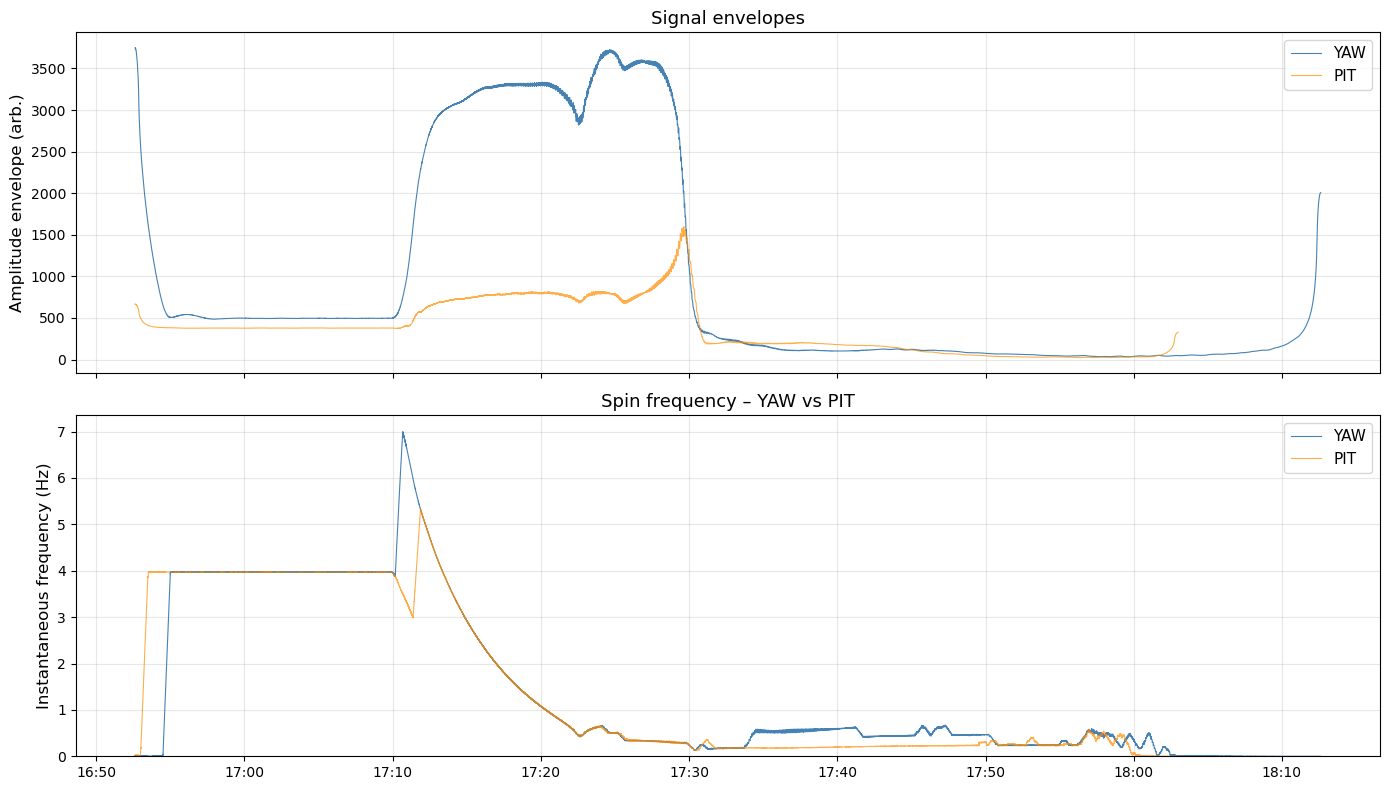

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# env arrays are now N-1 (trimmed), so use t_freq_ for both panels
axes[0].plot([gps_to_dt(t) for t in t_freq_yaw], env_yaw, linewidth=0.8,
             color='steelblue', label='YAW')
axes[0].plot([gps_to_dt(t) for t in t_freq_pit], env_pit, linewidth=0.8,
             color='darkorange', alpha=0.7, label='PIT')
axes[0].set_ylabel('Amplitude envelope (arb.)', fontsize=12)
axes[0].set_title('Signal envelopes', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot([gps_to_dt(t) for t in t_freq_yaw], freq_yaw, linewidth=0.8,
             color='steelblue', label='YAW')
axes[1].plot([gps_to_dt(t) for t in t_freq_pit], freq_pit, linewidth=0.8,
             color='darkorange', alpha=0.7, label='PIT')
axes[1].set_ylabel('Instantaneous frequency (Hz)', fontsize=12)
axes[1].set_title('Spin frequency – YAW vs PIT', fontsize=13)
axes[1].set_ylim(bottom=0)
axes[1].legend(fontsize=11)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[1].xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Drive-off (sinusoid):  2026-06-03 17:10:09.937500+00:00  (GPS 1464541828)


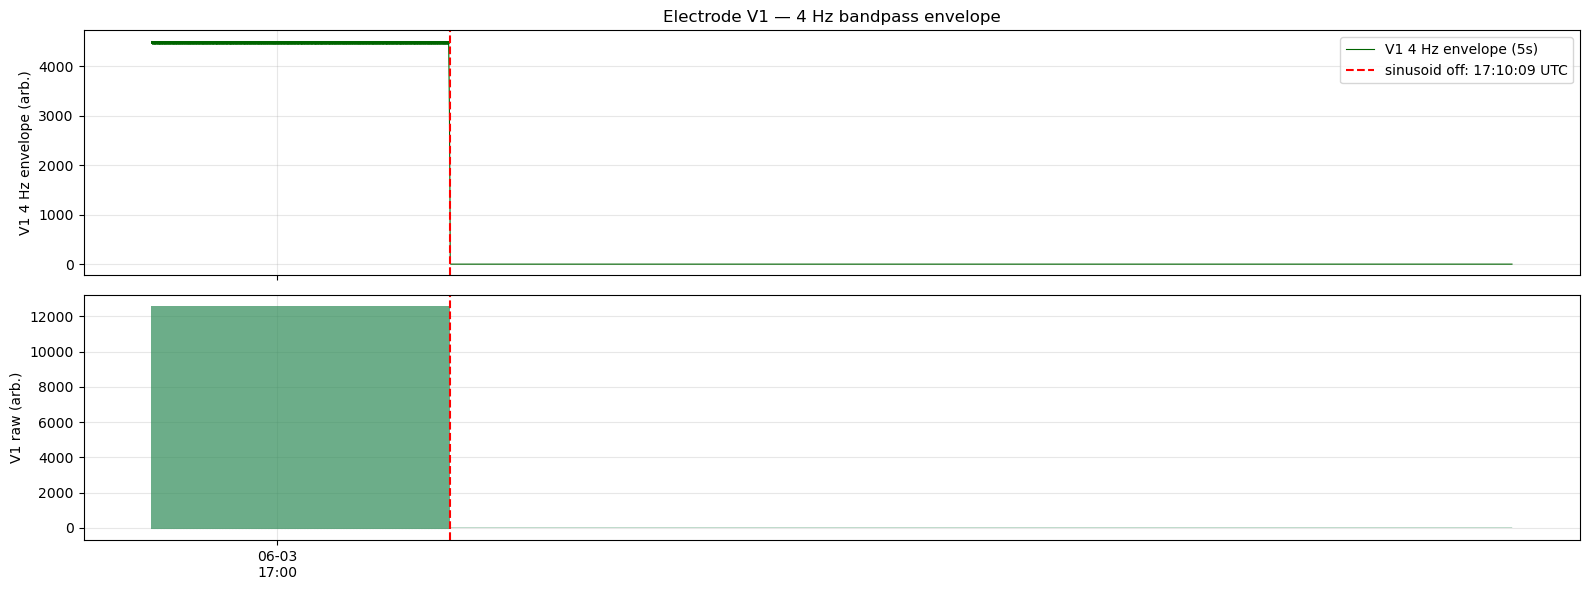

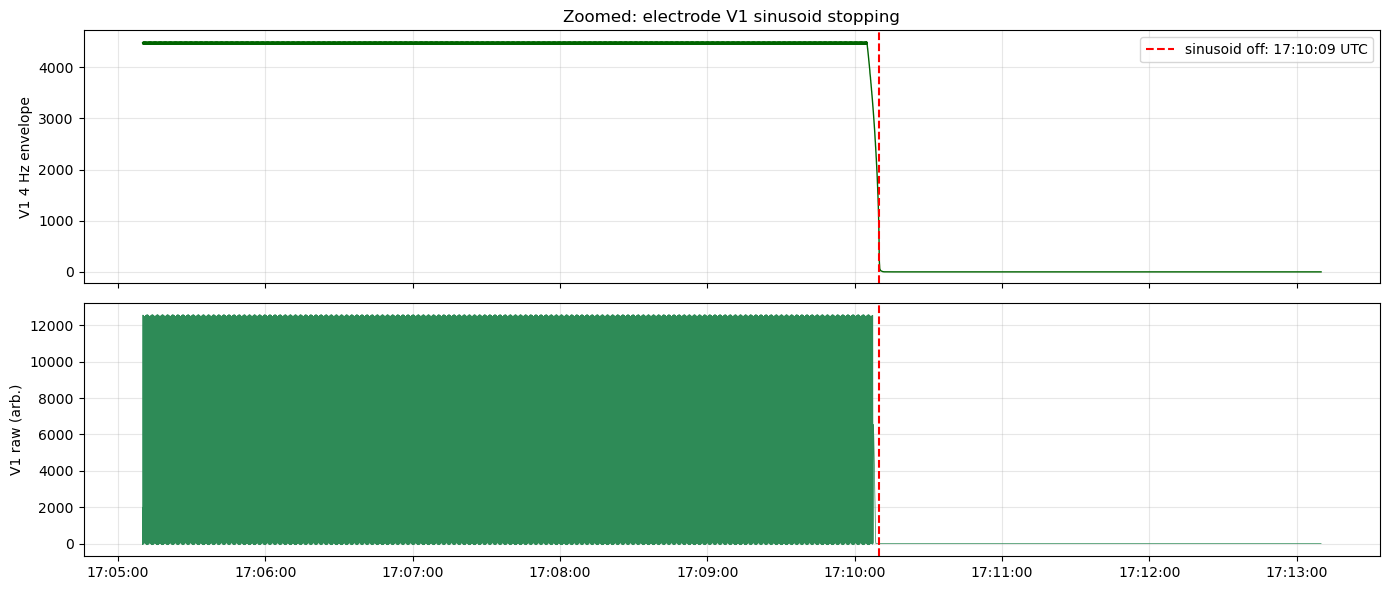

In [40]:
# Load electrode V1 at 64 Hz — preserves the 4 Hz sinusoidal drive
t_v1, y_v1 = load_channel(FILENAME_V1, fs_out=64.0)

# Isolate the 4 Hz drive component with a narrow bandpass, then take envelope
sos_el = butter(4, [2.0, 6.0], btype='bandpass', fs=64.0, output='sos')
y_v1_bp  = sosfiltfilt(sos_el, y_v1)
_win     = int(5 * 64)  # 5 s smoothing window
y_v1_env = np.sqrt(uniform_filter1d(y_v1_bp**2, size=_win))

# Drive-off: last sample where 4 Hz envelope > 10% of peak
env_thresh = 0.10 * y_v1_env.max()
driven_idx = np.where(y_v1_env > env_thresh)[0]
if len(driven_idx):
    drive_off_gps = t_v1[driven_idx[-1]]
    drive_off_dt  = gps_to_dt(drive_off_gps)
    print(f"Drive-off (sinusoid):  {drive_off_dt}  (GPS {drive_off_gps:.0f})")
else:
    print("Could not detect drive-off — adjust threshold")
    drive_off_dt = None

# ── Full overview ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
axes[0].plot([gps_to_dt(t) for t in t_v1], y_v1_env, linewidth=0.8,
             color='darkgreen', label='V1 4 Hz envelope (5s)')
if drive_off_dt:
    axes[0].axvline(drive_off_dt, color='red', linestyle='--', linewidth=1.5,
                    label=f'sinusoid off: {drive_off_dt.strftime("%H:%M:%S")} UTC')
axes[0].set_ylabel('V1 4 Hz envelope (arb.)'); axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)
axes[0].set_title('Electrode V1 — 4 Hz bandpass envelope')

axes[1].plot([gps_to_dt(t) for t in t_v1], y_v1, linewidth=0.3, color='seagreen', alpha=0.7)
if drive_off_dt:
    axes[1].axvline(drive_off_dt, color='red', linestyle='--', linewidth=1.5)
axes[1].set_ylabel('V1 raw (arb.)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=2))
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Zoomed: 10 min around drive-off ──────────────────────────────────────────
if drive_off_dt:
    zoom_gps0 = drive_off_gps - 5 * 60
    zoom_gps1 = drive_off_gps + 3 * 60
    zmask = (t_v1 >= zoom_gps0) & (t_v1 <= zoom_gps1)
    t_z = [gps_to_dt(t) for t in t_v1[zmask]]

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    axes[0].plot(t_z, y_v1_env[zmask], linewidth=1.0, color='darkgreen')
    axes[0].axvline(drive_off_dt, color='red', linestyle='--', linewidth=1.5,
                    label=f'sinusoid off: {drive_off_dt.strftime("%H:%M:%S")} UTC')
    axes[0].set_ylabel('V1 4 Hz envelope'); axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)
    axes[0].set_title('Zoomed: electrode V1 sinusoid stopping')

    axes[1].plot(t_z, y_v1[zmask], linewidth=0.5, color='seagreen')
    axes[1].axvline(drive_off_dt, color='red', linestyle='--', linewidth=1.5)
    axes[1].set_ylabel('V1 raw (arb.)')
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    axes[1].xaxis.set_major_locator(mdates.MinuteLocator(interval=1))
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

Electrode ramp-down start:  2026-06-03 17:10:09.953125+00:00  (GPS 1464541828)
                            0.0 min after sinusoid off


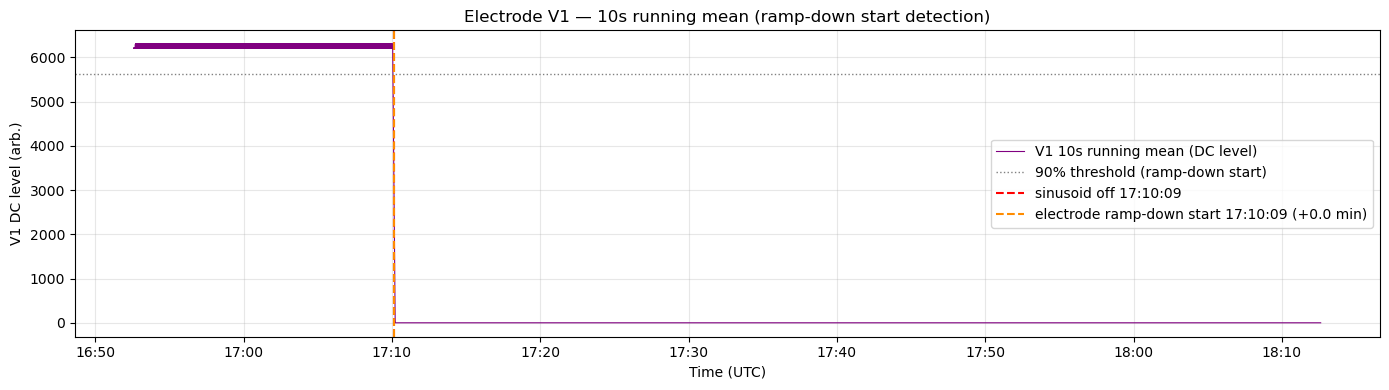

In [41]:
# DC electrode ramp-down detection: 10-second running mean of raw V1
# Electrodes have a non-trivial die-off time — disk responds as soon as field starts dropping.
# Detect the START of the ramp-down (first crossing below 90% of plateau).
DC_WIN = int(10 * 64)  # 10 s window at 64 Hz
y_v1_dc = uniform_filter1d(y_v1, size=DC_WIN)

pre_mask     = t_v1 < drive_off_gps
dc_level     = np.abs(y_v1_dc[pre_mask]).mean()
post_mask_dc = t_v1 > drive_off_gps
dc_off_candidates = np.where(post_mask_dc & (np.abs(y_v1_dc) < 0.90 * dc_level))[0]

if len(dc_off_candidates):
    dc_off_gps = t_v1[dc_off_candidates[0]]
    dc_off_dt  = gps_to_dt(dc_off_gps)
    dc_off_min = (dc_off_gps - drive_off_gps) / 60.0
    print(f"Electrode ramp-down start:  {dc_off_dt}  (GPS {dc_off_gps:.0f})")
    print(f"                            {dc_off_min:.1f} min after sinusoid off")
else:
    print("Electrode ramp-down not detected — adjust threshold or window")
    dc_off_gps = None

# Plot DC level vs time
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot([gps_to_dt(t) for t in t_v1], y_v1_dc, linewidth=0.8, color='purple',
        label='V1 10s running mean (DC level)')
ax.axhline(0.90 * dc_level, color='gray', linestyle=':', linewidth=1,
           label='90% threshold (ramp-down start)')
if drive_off_dt:
    ax.axvline(drive_off_dt, color='red', linestyle='--', linewidth=1.5,
               label=f'sinusoid off {drive_off_dt.strftime("%H:%M:%S")}')
if dc_off_gps is not None:
    ax.axvline(dc_off_dt, color='darkorange', linestyle='--', linewidth=1.5,
               label=f'electrode ramp-down start {dc_off_dt.strftime("%H:%M:%S")} (+{dc_off_min:.1f} min)')
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('V1 DC level (arb.)')
ax.set_title('Electrode V1 — 10s running mean (ramp-down start detection)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Exponential Fit: Spindown Time
Fit f(t) = A · exp(−γt) to the cleanly decaying portion.  
- `F_MAX_FIT`: upper limit — exclude the plateau before the drive was off  
- `F_MIN_FIT`: lower limit — exclude noisy tail near zero  

τ = 1/γ is the 1/e spindown time.

In [63]:
# ── Choose which channel to fit ───────────────────────────────────────────────
USE_CHANNEL = 'PIT'   # 'PIT' or 'YAW' (YAW now uses IN1_DQ — both have signal)
# ─────────────────────────────────────────────────────────────────────────────

if USE_CHANNEL == 'YAW':
    t_fit_all, freq_fit_all, env_fit_all = t_freq_yaw, freq_yaw, env_yaw
else:
    t_fit_all, freq_fit_all, env_fit_all = t_freq_pit, freq_pit, env_pit

# ── Fit bounds ────────────────────────────────────────────────────────────────
F_MIN_FIT  = 1.0   # Hz – lower cutoff
AMP_THRESH = 0.05  # fraction of peak envelope (relaxed for post-drive-off)
# ─────────────────────────────────────────────────────────────────────────────

amp_peak = env_fit_all.max()

# ── Find peak frequency after drive-off, start fit from there ─────────────────
# The ball spins up briefly after electrode cutoff before free decay begins.
# The true exponential decay starts at the peak.
post_drive_mask = t_fit_all > drive_off_gps
peak_idx = np.argmax(freq_fit_all[post_drive_mask])
t_peak   = t_fit_all[post_drive_mask][peak_idx]
f_peak   = freq_fit_all[post_drive_mask][peak_idx]
t_start  = t_peak  # used by later cells

print(f"Peak: {f_peak:.3f} Hz at {gps_to_dt(t_peak)}  (+{(t_peak - drive_off_gps)/60:.1f} min after drive-off)")

fit_mask = (
    (freq_fit_all > F_MIN_FIT) &
    (env_fit_all  > AMP_THRESH * amp_peak) &
    (t_fit_all    >= t_peak)
)

t_fit_gps = t_fit_all[fit_mask]
f_fit     = freq_fit_all[fit_mask]

print(f"Using: {USE_CHANNEL}  |  {len(f_fit)} points in fit region")
if len(f_fit) > 0:
    print(f"  {gps_to_dt(t_fit_gps[0])} → {gps_to_dt(t_fit_gps[-1])}")
    print(f"  span: {(t_fit_gps[-1] - t_fit_gps[0]) / 60:.1f} min")
    print(f"  freq range: {f_fit.min():.3f} – {f_fit.max():.3f} Hz")

Peak: 5.325 Hz at 2026-06-03 17:11:52.585938+00:00  (+1.7 min after drive-off)
Using: PIT  |  32444 points in fit region
  2026-06-03 17:11:52.585938+00:00 → 2026-06-03 17:20:20.960938+00:00
  span: 8.5 min
  freq range: 1.000 – 5.325 Hz


In [64]:
if len(f_fit) < 20:
    print("WARNING: too few points — adjust F_MIN_FIT / F_MAX_FIT or RING_START / RING_END")
else:
    t0  = t_fit_gps[0]
    t_s = t_fit_gps - t0  # seconds from start of fit region

    def exp_decay(t, A, gamma):
        return A * np.exp(-gamma * t)

    popt, pcov = curve_fit(exp_decay, t_s, f_fit,
                           p0=[f_fit[0], 1e-3], maxfev=10000)
    A_fit, gamma_fit = popt
    A_err, gamma_err = np.sqrt(np.diag(pcov))

    tau     = 1.0 / gamma_fit
    tau_err = gamma_err / gamma_fit**2

    print(f"=== Spindown Results ===")
    print(f"γ  = {gamma_fit:.6f} ± {gamma_err:.6f}  s⁻¹")
    print(f"τ  = {tau:.1f} ± {tau_err:.1f}  s")
    print(f"τ  = {tau/60:.2f} ± {tau_err/60:.2f}  min")
    print(f"A  = {A_fit:.4f} Hz  (extrapolated initial frequency)")

=== Spindown Results ===
γ  = 0.003217 ± 0.000000  s⁻¹
τ  = 310.9 ± 0.0  s
τ  = 5.18 ± 0.00  min
A  = 5.3220 Hz  (extrapolated initial frequency)


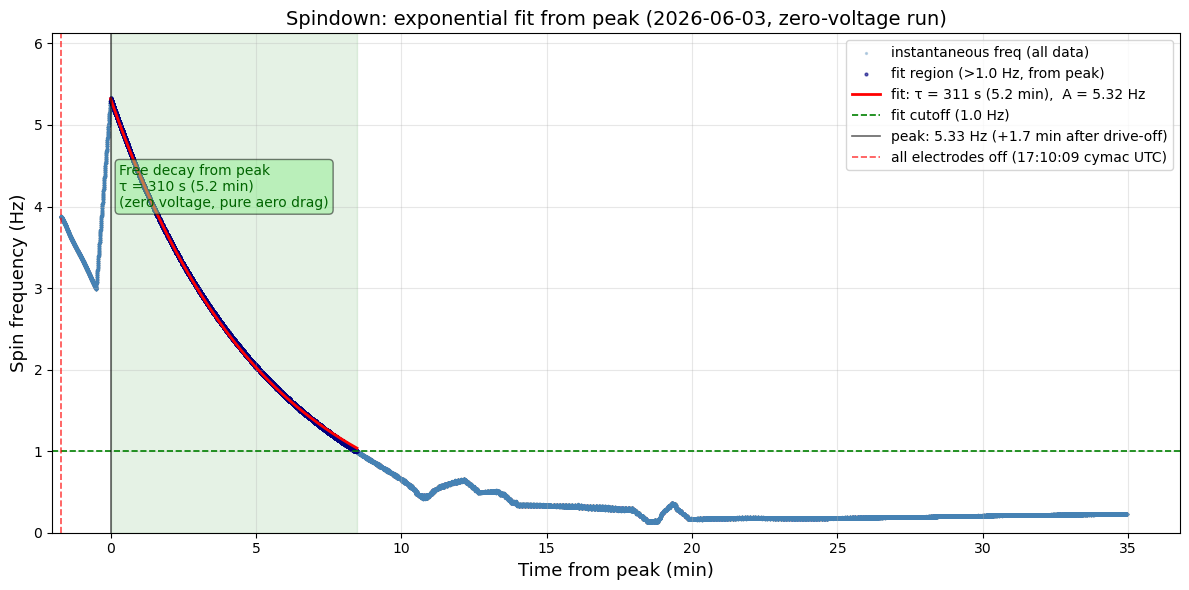

In [65]:
if len(f_fit) >= 20:
    # All post-drive-off data for context
    post_mask = (
        (t_fit_all > drive_off_gps) &
        (env_fit_all > 0.05 * amp_peak) &
        (freq_fit_all > 0.05)
    )
    t_all_s = (t_fit_all[post_mask] - t_peak) / 60.0
    f_all   = freq_fit_all[post_mask]

    t0      = t_fit_gps[0]
    t_s     = t_fit_gps - t0
    t_curve = np.linspace(0, t_s[-1], 1000)
    t_exp_end = t_s[-1] / 60.0

    drive_off_rel = (drive_off_gps - t_peak) / 60.0  # negative (before peak)

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.axvspan(0, t_exp_end, alpha=0.10, color='green', label='_nolegend_')

    ax.scatter(t_all_s, f_all, s=2, alpha=0.3, color='steelblue', label='instantaneous freq (all data)')
    ax.scatter(t_s / 60, f_fit, s=4, alpha=0.6, color='navy', label=f'fit region (>{F_MIN_FIT} Hz, from peak)')
    ax.plot(t_curve / 60, exp_decay(t_curve, *popt), 'r-', linewidth=2,
            label=f'fit: τ = {tau:.0f} s ({tau/60:.1f} min),  A = {A_fit:.2f} Hz')

    ax.axhline(F_MIN_FIT, color='green', linestyle='--', linewidth=1.2,
               label=f'fit cutoff ({F_MIN_FIT} Hz)')
    ax.axvline(0, color='black', linestyle='-', linewidth=1.2, alpha=0.6,
               label=f'peak: {f_peak:.2f} Hz (+{(t_peak-drive_off_gps)/60:.1f} min after drive-off)')
    ax.axvline(drive_off_rel, color='red', linestyle='--', linewidth=1.2, alpha=0.7,
               label=f'all electrodes off ({drive_off_dt.strftime("%H:%M:%S")} cymac UTC)')

    ax.text(0.3, f_peak * 0.75,
            'Free decay from peak\nτ = {:d} s ({:.1f} min)\n(zero voltage, pure aero drag)'.format(int(tau), tau/60),
            fontsize=10, color='darkgreen',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.5))

    ax.set_xlim(left=drive_off_rel - 0.3)
    ax.set_ylim(bottom=0, top=f_peak * 1.15)
    ax.set_xlabel('Time from peak (min)', fontsize=13)
    ax.set_ylabel('Spin frequency (Hz)', fontsize=13)
    ax.set_title('Spindown: exponential fit from peak (2026-06-03, zero-voltage run)', fontsize=14)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

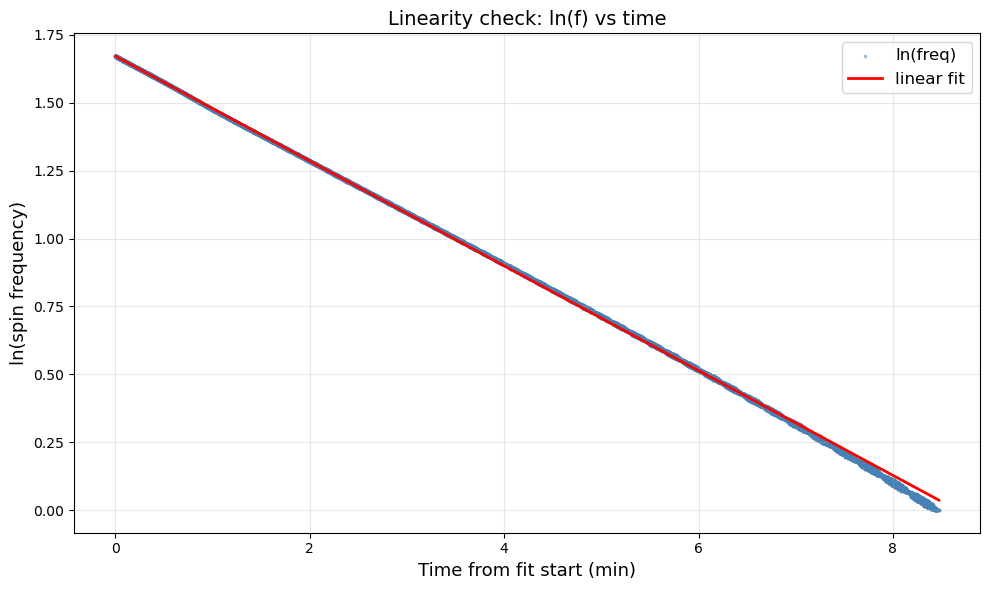

In [66]:
# Linearity check: ln(f) vs time should be a straight line for pure exponential decay
if len(f_fit) >= 20:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(t_s / 60, np.log(f_fit), s=3, alpha=0.4, color='steelblue', label='ln(freq)')
    ax.plot(t_curve / 60, np.log(exp_decay(t_curve, *popt)), 'r-', linewidth=2, label='linear fit')
    ax.set_xlabel('Time from fit start (min)', fontsize=13)
    ax.set_ylabel('ln(spin frequency)', fontsize=13)
    ax.set_title('Linearity check: ln(f) vs time', fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

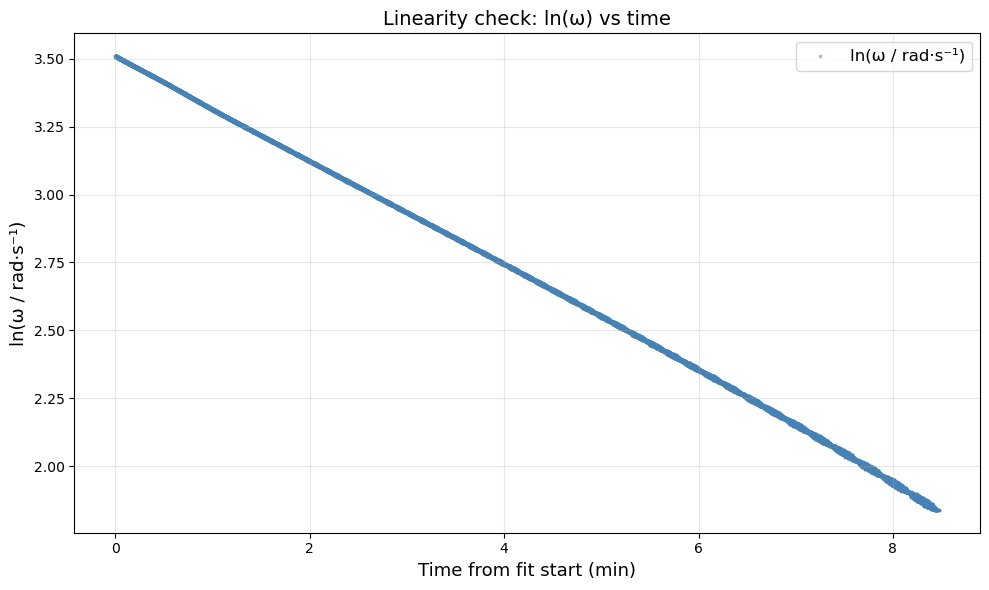

In [68]:
# Linearity check: ln(ω) vs time — identical slope to ln(f), y-axis in rad/s
# ln(ω) = ln(2πf) = ln(f) + ln(2π); same γ, same τ
if len(f_fit) >= 20:
    omega_fit  = 2 * np.pi * f_fit
    t_curve_fit = np.linspace(t_s[0], t_s[-1], 1000)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(t_s / 60, np.log(omega_fit), s=3, alpha=0.4, color='steelblue', label='ln(ω / rad·s⁻¹)')
#     ax.plot(t_curve_fit / 60, np.log(2 * np.pi * exp_decay(t_curve_fit, *popt)),
#             'r-', linewidth=2, label=f'linear fit: slope = −γ = −1/τ  (τ = {tau:.0f} s)')
    ax.set_xlabel('Time from fit start (min)', fontsize=13)
    ax.set_ylabel('ln(ω / rad·s⁻¹)', fontsize=13)
    ax.set_title('Linearity check: ln(ω) vs time', fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

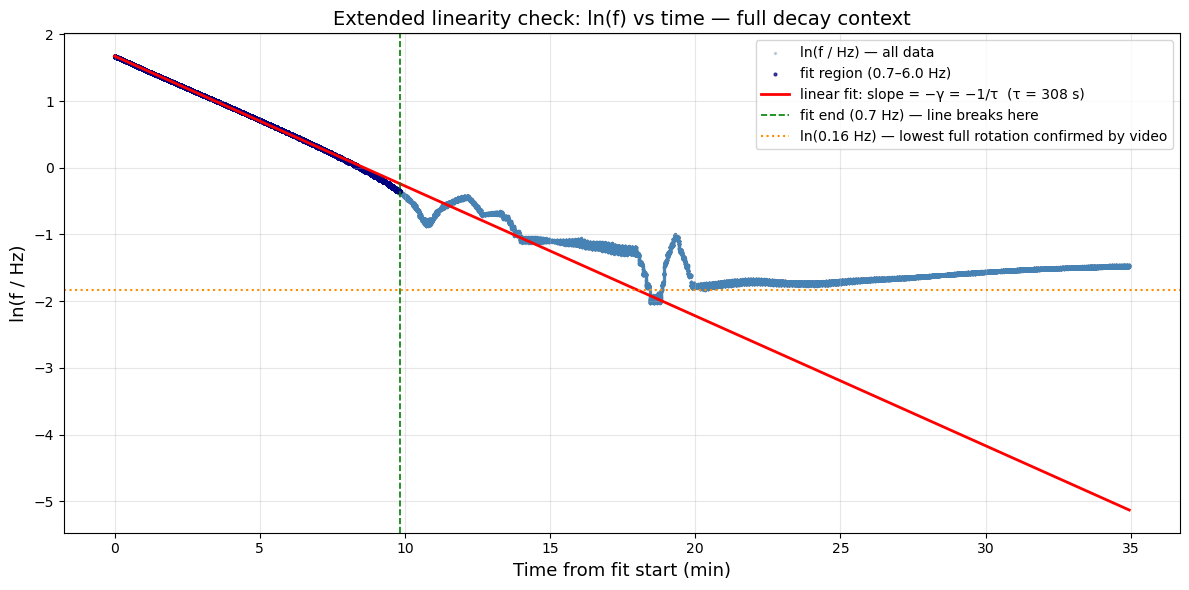

In [56]:
# Extended linearity check: show ALL post-drive-off data in log space
# ln(f) vs time — if purely exponential, this is a straight line with slope -γ = -1/τ
# Note: ln(ω) = ln(2πf) = ln(f) + ln(2π), so it's the same line shifted up by ~1.84; slope unchanged
if len(f_fit) >= 20:
    post_mask = (
        (t_fit_all > t_start) &
        (env_fit_all > 0.05 * amp_peak) &
        (freq_fit_all > 0.05) &
        (freq_fit_all < F_MAX_FIT)
    )
    t_all_s = (t_fit_all[post_mask] - t_fit_gps[0]) / 60.0
    f_all   = freq_fit_all[post_mask]

    t_curve_long = np.linspace(0, t_all_s.max(), 2000)

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.scatter(t_all_s, np.log(f_all), s=2, alpha=0.3, color='steelblue', label='ln(f / Hz) — all data')
    ax.scatter(t_s / 60, np.log(f_fit), s=4, alpha=0.7, color='navy', label=f'fit region ({F_MIN_FIT}–{F_MAX_FIT} Hz)')
    ax.plot(t_curve_long, np.log(A_fit) - gamma_fit * t_curve_long * 60,
            'r-', linewidth=2, label=f'linear fit: slope = −γ = −1/τ  (τ = {tau:.0f} s)')

    ax.axvline(t_s[-1] / 60, color='green', linestyle='--', linewidth=1.2,
               label=f'fit end ({F_MIN_FIT} Hz) — line breaks here')
    ax.axhline(np.log(0.16), color='darkorange', linestyle=':', linewidth=1.5,
               label='ln(0.16 Hz) — lowest full rotation confirmed by video')

    ax.set_xlabel('Time from fit start (min)', fontsize=13)
    ax.set_ylabel('ln(f / Hz)', fontsize=13)
    ax.set_title('Extended linearity check: ln(f) vs time — full decay context', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Results Summary

In [57]:
if len(f_fit) >= 20:
    print("=" * 40)
    print("SPINDOWN RESULTS")
    print("=" * 40)
    print(f"Decay constant:  γ = {gamma_fit:.6f} ± {gamma_err:.6f} s⁻¹")
    print(f"Spindown time:   τ = {tau:.1f} ± {tau_err:.1f} s")
    print(f"                   = {tau/60:.2f} ± {tau_err/60:.2f} min")
    print(f"Initial freq:    A = {A_fit:.4f} Hz")
    print(f"Fit region:      {F_MIN_FIT}–{F_MAX_FIT} Hz  ({len(f_fit)} points)")
    print(f"Smoothing:       {SMOOTH_SEC}s window")

SPINDOWN RESULTS
Decay constant:  γ = 0.003246 ± 0.000000 s⁻¹
Spindown time:   τ = 308.1 ± 0.0 s
                   = 5.13 ± 0.00 min
Initial freq:    A = 5.3380 Hz
Fit region:      0.7–6.0 Hz  (37624 points)
Smoothing:       30.0s window
